---
## 1. Carga del dataset tratado

In [1]:
import requests
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             average_precision_score, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE

PALETA = ["#2ecc71", "#e74c3c"]
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()
df_raw = pd.json_normalize(data)

df_raw.columns = (
    df_raw.columns
    .str.replace(r'^customer\.', '', regex=True)
    .str.replace(r'^phone\.', '', regex=True)
    .str.replace(r'^internet\.', '', regex=True)
    .str.replace(r'^account\.', '', regex=True)
    .str.replace(r'^Charges\.', '', regex=True)
)

df_raw["Total"] = pd.to_numeric(df_raw["Total"], errors="coerce")
df_raw["Churn"] = df_raw["Churn"].str.strip()
df_raw = df_raw[df_raw["Churn"] != ""].copy()
df_raw["Total"] = df_raw["Total"].fillna(df_raw["Monthly"])
for col in df_raw.select_dtypes(include="object").columns:
    df_raw[col] = df_raw[col].str.strip()

df_raw["Cuentas_Diarias"] = (df_raw["Monthly"] / 30).round(4)

cols_bin = ["Partner","Dependents","PhoneService","PaperlessBilling",
            "MultipleLines","OnlineSecurity","OnlineBackup",
            "DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
mapa_bin = {"Yes":1,"No":0,"No phone service":0,"No internet service":0}
for col in cols_bin:
    df_raw[col] = df_raw[col].map(mapa_bin)

df_raw["Churn"]           = df_raw["Churn"].map({"Yes":1,"No":0})
df_raw["InternetService"] = df_raw["InternetService"].map({"DSL":1,"Fiber optic":2,"No":0})
df_raw["Contract"]        = df_raw["Contract"].map({"Month-to-month":0,"One year":1,"Two year":2})
df_raw["PaymentMethod"]   = df_raw["PaymentMethod"].map({
    "Electronic check":0,"Mailed check":1,
    "Bank transfer (automatic)":2,"Credit card (automatic)":3})
df_raw["gender"]          = df_raw["gender"].map({"Male":1,"Female":0})

df_raw = df_raw.rename(columns={
    "customerID":"ID_Cliente","Churn":"Evasion","gender":"Genero",
    "SeniorCitizen":"Adulto_Mayor","Partner":"Tiene_Pareja","Dependents":"Tiene_Dependientes",
    "tenure":"Meses_Contrato","PhoneService":"Servicio_Telefono","MultipleLines":"Lineas_Multiples",
    "InternetService":"Tipo_Internet","OnlineSecurity":"Seguridad_Online",
    "OnlineBackup":"Respaldo_Online","DeviceProtection":"Proteccion_Dispositivo",
    "TechSupport":"Soporte_Tecnico","StreamingTV":"Streaming_TV",
    "StreamingMovies":"Streaming_Peliculas","Contract":"Tipo_Contrato",
    "PaperlessBilling":"Factura_Electronica","PaymentMethod":"Metodo_Pago",
    "Monthly":"Cargo_Mensual","Total":"Cargo_Total","Cuentas_Diarias":"Cargo_Diario"
})

print(f"Datos cargados desde API — Shape: {df_raw.shape}")
df_raw.head()

Datos cargados desde API — Shape: (7043, 22)


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Tipo_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,0,0,0,1,1,9,1,0,1,...,0,1,1,0,1,1,1,65.6,593.30,2.1867
1,0003-MKNFE,0,1,0,0,0,9,1,1,1,...,0,0,0,1,0,0,1,59.9,542.40,1.9967
2,0004-TLHLJ,1,1,0,0,0,4,1,0,2,...,1,0,0,0,0,1,0,73.9,280.85,2.4633
3,0011-IGKFF,1,1,1,1,0,13,1,0,2,...,1,0,1,1,0,1,0,98.0,1237.85,3.2667
4,0013-EXCHZ,1,0,1,1,0,3,1,0,2,...,0,1,1,0,0,1,1,83.9,267.40,2.7967


---
## 2. Eliminacion de columnas sin valor predictivo



In [3]:
df = df_raw.drop(columns=["ID_Cliente"])
print(f"Shape tras eliminar ID_Cliente: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Shape tras eliminar ID_Cliente: (7043, 21)
Columnas: ['Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Lineas_Multiples', 'Tipo_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Electronica', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']


---
## 3. Codificacion de variables categoricas con One-Hot Encoding


In [4]:
mapas = {
    "Tipo_Internet" : {0: "Sin_Internet",   1: "DSL",            2: "Fibra_Optica"},
    "Tipo_Contrato" : {0: "Mes_a_mes",      1: "Un_anio",        2: "Dos_anios"},
    "Metodo_Pago"   : {0: "Cheque_elect",   1: "Cheque_postal",
                       2: "Trans_bancaria", 3: "Tarjeta_credito"},
}
df_ohe = df.copy()
for col, mapa in mapas.items():
    df_ohe[col] = df_ohe[col].map(mapa)

df_encoded = pd.get_dummies(df_ohe, columns=list(mapas.keys()), drop_first=False, dtype=int)

print(f"Columnas antes : {df.shape[1]}")
print(f"Columnas despues: {df_encoded.shape[1]}")
nuevas = [c for c in df_encoded.columns if c not in df.columns]
print(f"Columnas OHE generadas: {nuevas}")

Columnas antes : 21
Columnas despues: 28
Columnas OHE generadas: ['Tipo_Internet_DSL', 'Tipo_Internet_Fibra_Optica', 'Tipo_Internet_Sin_Internet', 'Tipo_Contrato_Dos_anios', 'Tipo_Contrato_Mes_a_mes', 'Tipo_Contrato_Un_anio', 'Metodo_Pago_Cheque_elect', 'Metodo_Pago_Cheque_postal', 'Metodo_Pago_Tarjeta_credito', 'Metodo_Pago_Trans_bancaria']


---
## 4. Analisis del desbalanceo de clases

           Cantidad  Porcentaje (%)
Evasion                            
Permanece      5174           73.46
Evade          1869           26.54

Ratio de desbalanceo: 2.77 : 1


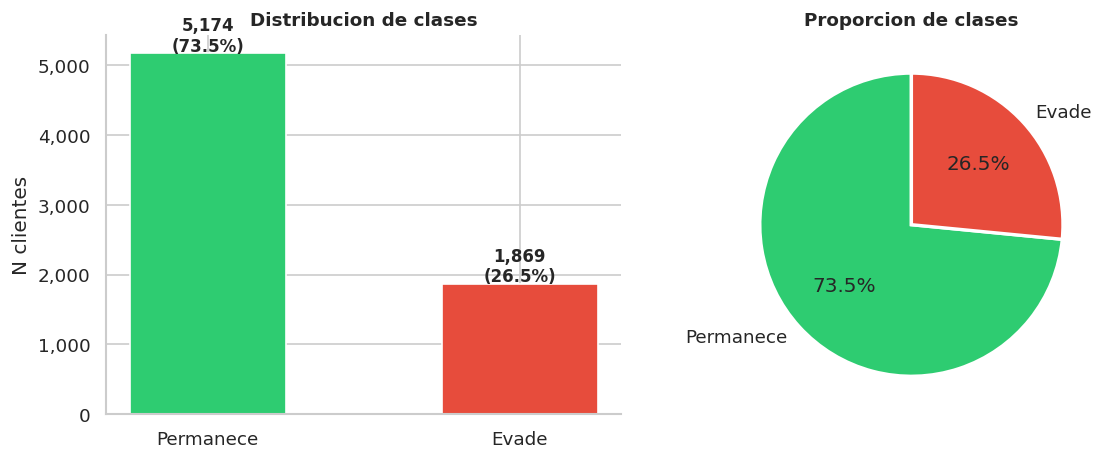

In [5]:
conteo = df_encoded["Evasion"].value_counts().rename({0: "Permanece", 1: "Evade"})
pct    = df_encoded["Evasion"].value_counts(normalize=True).mul(100).round(2).rename({0: "Permanece", 1: "Evade"})

print(pd.DataFrame({"Cantidad": conteo, "Porcentaje (%)": pct}))
print(f"\nRatio de desbalanceo: {conteo['Permanece']/conteo['Evade']:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(conteo.index, conteo.values, color=PALETA, edgecolor="white", width=0.5)
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    axes[0].text(i, v + 30, f"{v:,}\n({p:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Distribucion de clases", fontsize=11, fontweight="bold")
axes[0].set_ylabel("N clientes")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].pie(conteo.values, labels=conteo.index, colors=PALETA, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Proporcion de clases", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Matriz de correlacion y relacion de variables con la cancelacion


### 5.1 Matriz de correlacion completa

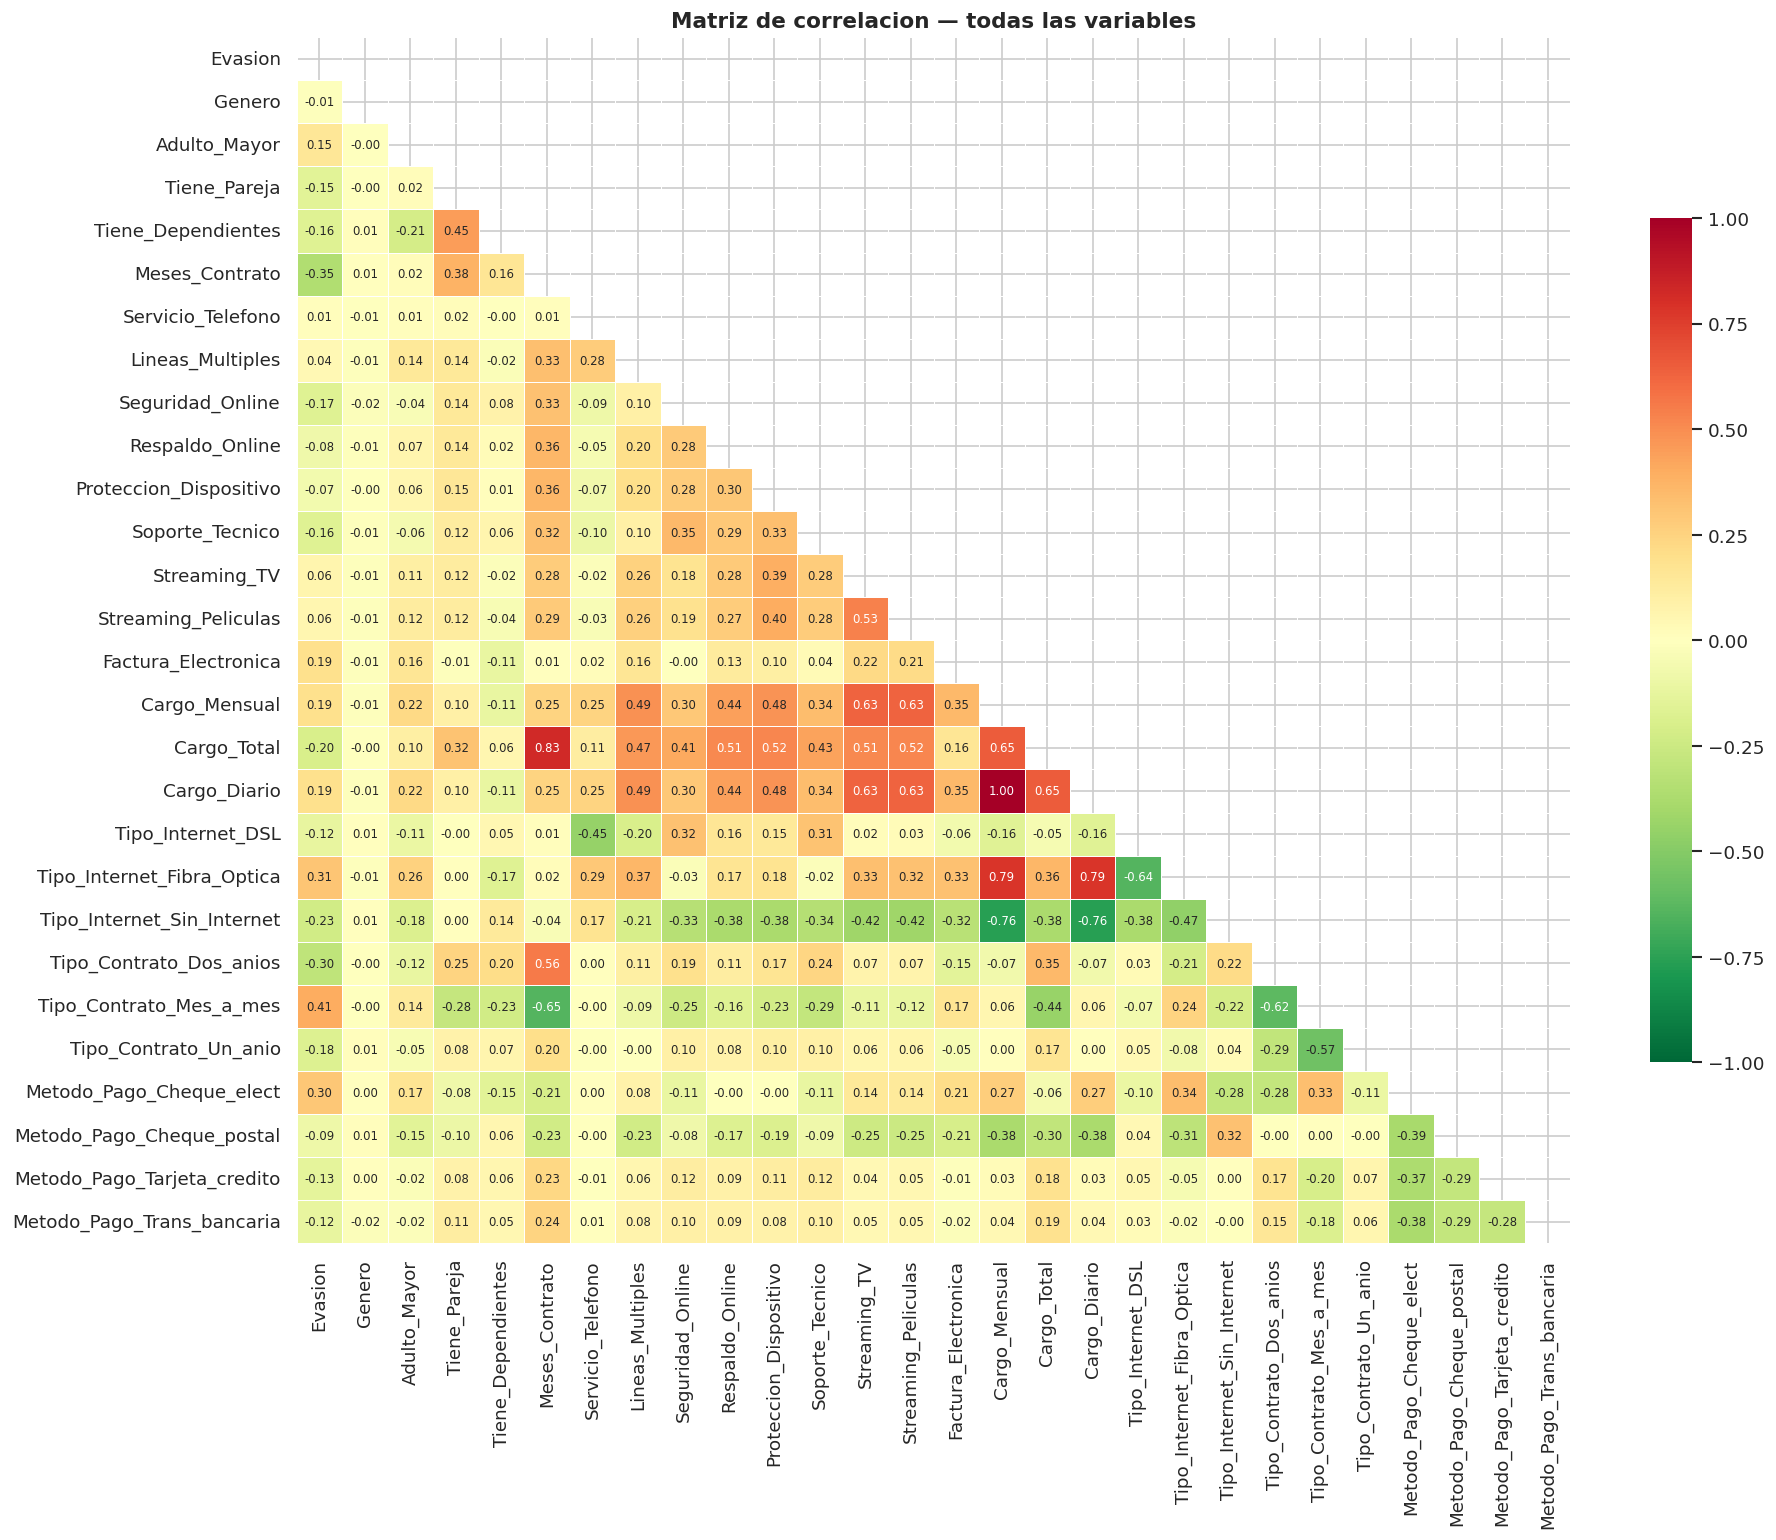

In [6]:
X_all = df_encoded.drop(columns=["Evasion"])
corr_matrix = df_encoded.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn_r", center=0, linewidths=0.3, ax=ax,
    annot_kws={"size": 7}, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.7}
)
ax.set_title("Matriz de correlacion — todas las variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 Correlacion de cada variable con Evasion

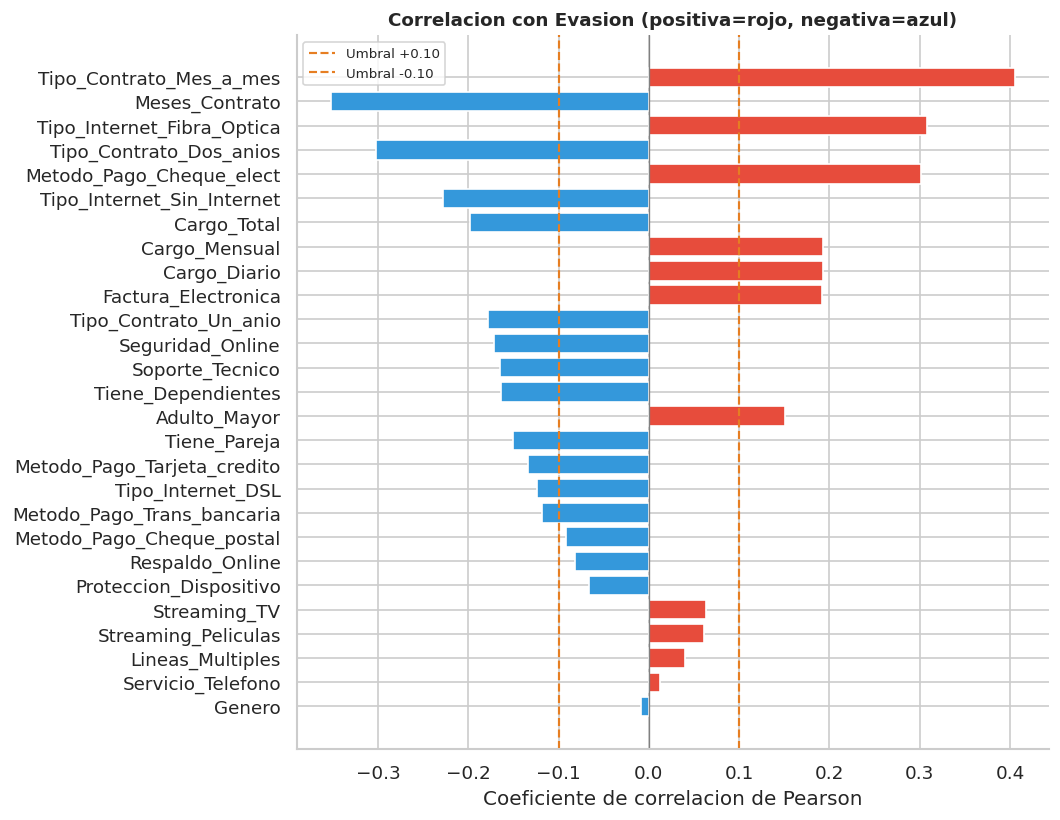

Top 8 variables mas correlacionadas con Evasion:
Tipo_Contrato_Mes_a_mes       0.4051
Meses_Contrato               -0.3522
Tipo_Internet_Fibra_Optica    0.3080
Tipo_Contrato_Dos_anios      -0.3023
Metodo_Pago_Cheque_elect      0.3019
Tipo_Internet_Sin_Internet   -0.2279
Cargo_Total                  -0.1983
Cargo_Mensual                 0.1934
Name: Evasion, dtype: float64


In [7]:
corr_evasion = corr_matrix["Evasion"].drop("Evasion").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colores_bar = ["#e74c3c" if v > 0 else "#3498db" for v in corr_evasion.values]
ax.barh(corr_evasion.index[::-1], corr_evasion.values[::-1],
        color=colores_bar[::-1], edgecolor="white")
ax.axvline(0.10,  color="#e67e22", linestyle="--", lw=1.3, label="Umbral +0.10")
ax.axvline(-0.10, color="#e67e22", linestyle="--", lw=1.3, label="Umbral -0.10")
ax.axvline(0, color="gray", lw=0.8)
ax.set_title("Correlacion con Evasion (positiva=rojo, negativa=azul)", fontsize=11, fontweight="bold")
ax.set_xlabel("Coeficiente de correlacion de Pearson")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Top 8 variables mas correlacionadas con Evasion:")
print(corr_evasion.head(8).round(4))

### 5.3 Tiempo de contrato x Cancelacion (boxplot + distribucion)

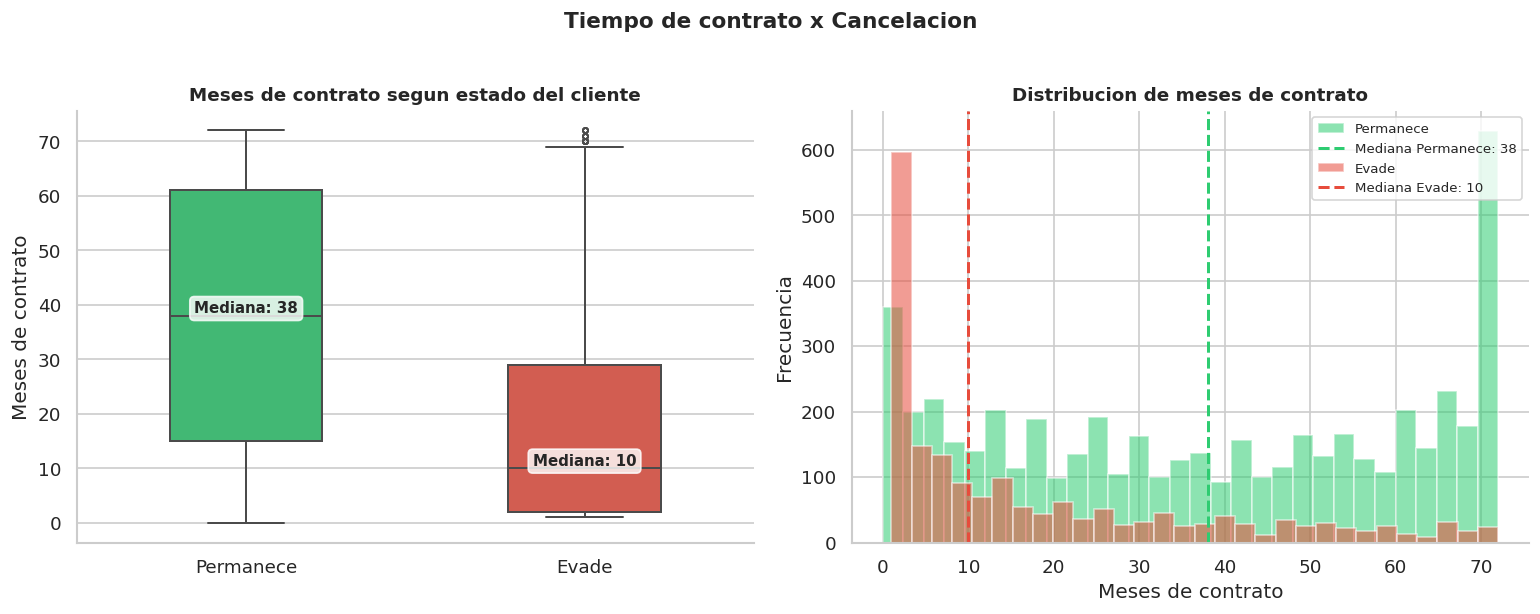

In [8]:
df_plot = df_encoded.copy()
df_plot["Estado"] = df_plot["Evasion"].map({0: "Permanece", 1: "Evade"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_plot, x="Estado", y="Meses_Contrato",
            palette={"Permanece": "#2ecc71", "Evade": "#e74c3c"},
            width=0.45, linewidth=1.2, fliersize=3, ax=axes[0])
for i, estado in enumerate(["Permanece", "Evade"]):
    med = df_plot[df_plot["Estado"] == estado]["Meses_Contrato"].median()
    axes[0].text(i, med + 0.5, f"Mediana: {med:.0f}", ha="center",
                 fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
axes[0].set_title("Meses de contrato segun estado del cliente", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Meses de contrato")

for estado, color in zip(["Permanece", "Evade"], PALETA):
    datos = df_plot[df_plot["Estado"] == estado]["Meses_Contrato"]
    axes[1].hist(datos, bins=30, alpha=0.55, color=color, label=estado, edgecolor="white")
    axes[1].axvline(datos.median(), color=color, linestyle="--", lw=1.8,
                    label=f"Mediana {estado}: {datos.median():.0f}")
axes[1].set_title("Distribucion de meses de contrato", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Meses de contrato")
axes[1].set_ylabel("Frecuencia")
axes[1].legend(fontsize=8)

plt.suptitle("Tiempo de contrato x Cancelacion", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Gasto total x Cancelacion (boxplot + scatter)

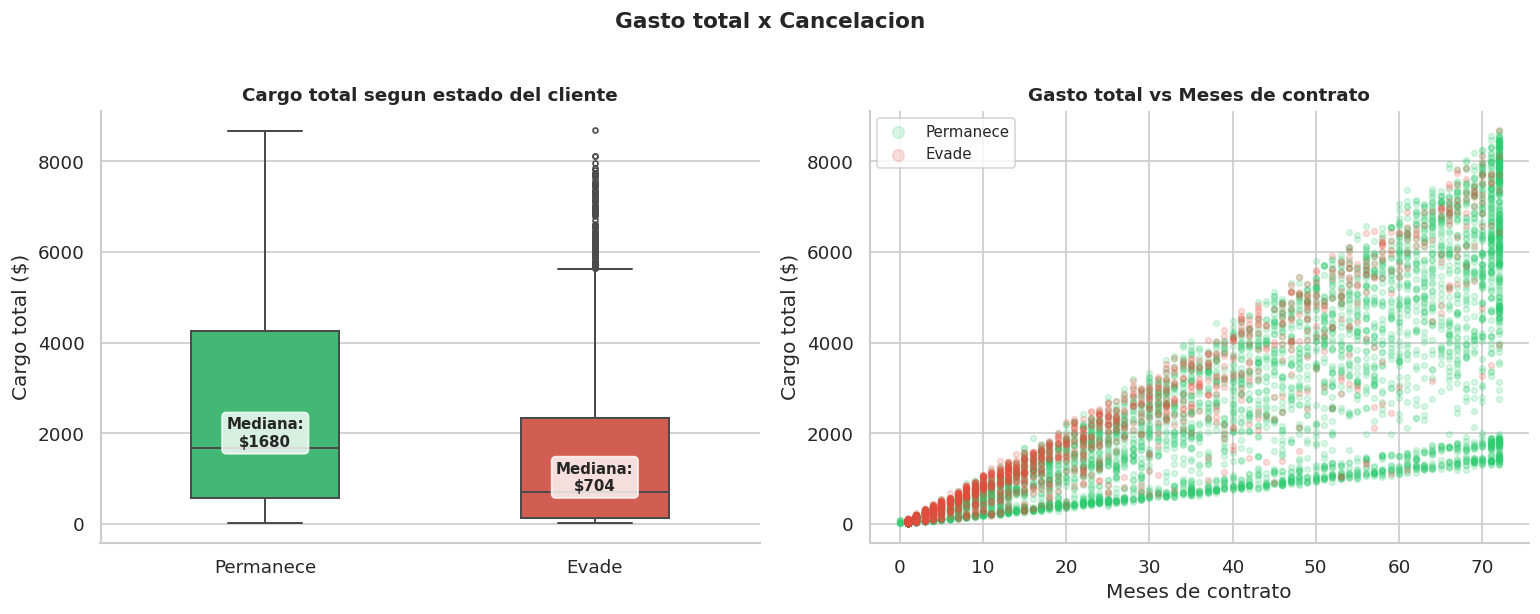

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_plot, x="Estado", y="Cargo_Total",
            palette={"Permanece": "#2ecc71", "Evade": "#e74c3c"},
            width=0.45, linewidth=1.2, fliersize=3, ax=axes[0])
for i, estado in enumerate(["Permanece", "Evade"]):
    med = df_plot[df_plot["Estado"] == estado]["Cargo_Total"].median()
    axes[0].text(i, med + 30, f"Mediana:\n${med:.0f}", ha="center",
                 fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
axes[0].set_title("Cargo total segun estado del cliente", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cargo total ($)")

for estado, color in zip(["Permanece", "Evade"], PALETA):
    sub = df_plot[df_plot["Estado"] == estado]
    axes[1].scatter(sub["Meses_Contrato"], sub["Cargo_Total"],
                    alpha=0.18, color=color, s=12, label=estado)
axes[1].set_title("Gasto total vs Meses de contrato", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Meses de contrato")
axes[1].set_ylabel("Cargo total ($)")
axes[1].legend(fontsize=9, markerscale=2)

plt.suptitle("Gasto total x Cancelacion", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Cargo mensual x Cancelacion

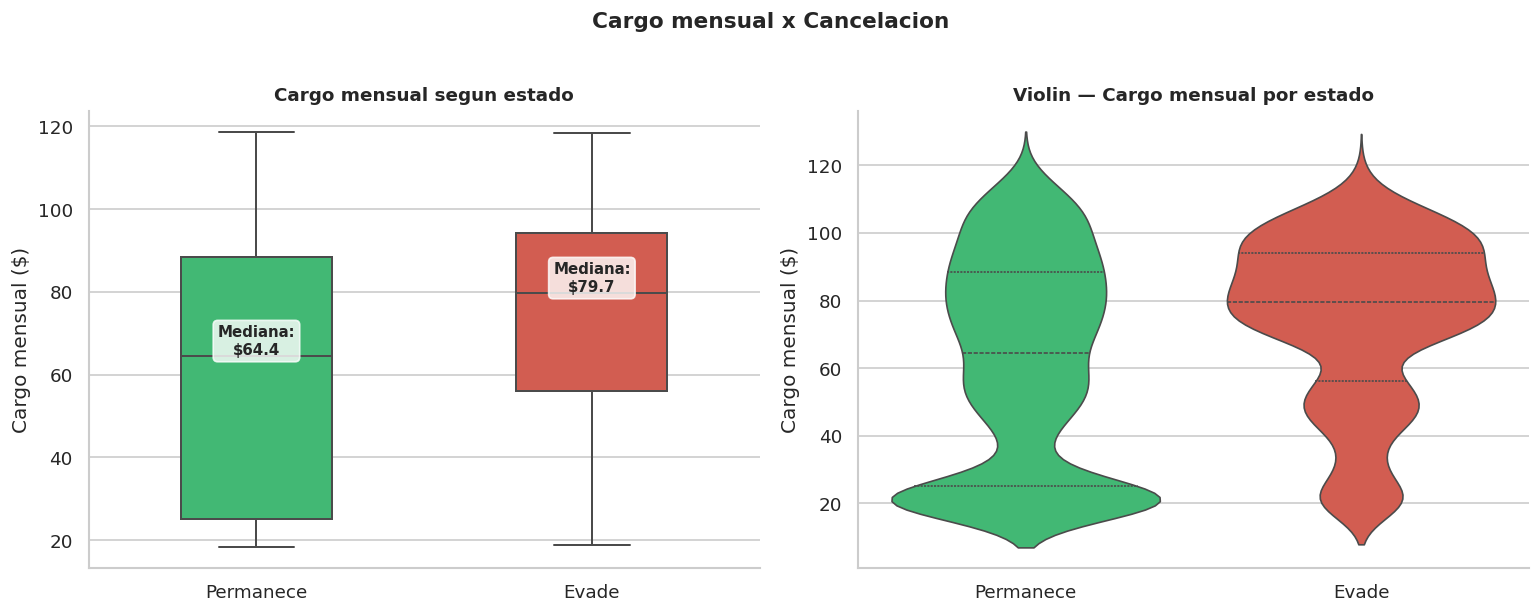

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_plot, x="Estado", y="Cargo_Mensual",
            palette={"Permanece":"#2ecc71","Evade":"#e74c3c"},
            width=0.45, linewidth=1.2, fliersize=3, ax=axes[0])
for i, estado in enumerate(["Permanece","Evade"]):
    med = df_plot[df_plot["Estado"]==estado]["Cargo_Mensual"].median()
    axes[0].text(i, med+0.5, f"Mediana:\n${med:.1f}", ha="center", fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
axes[0].set_title("Cargo mensual segun estado", fontsize=11, fontweight="bold")
axes[0].set_xlabel(""); axes[0].set_ylabel("Cargo mensual ($)")

sns.violinplot(data=df_plot, x="Estado", y="Cargo_Mensual",
               palette={"Permanece":"#2ecc71","Evade":"#e74c3c"},
               inner="quartile", linewidth=1, ax=axes[1])
axes[1].set_title("Violin — Cargo mensual por estado", fontsize=11, fontweight="bold")
axes[1].set_xlabel(""); axes[1].set_ylabel("Cargo mensual ($)")

plt.suptitle("Cargo mensual x Cancelacion", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Seleccion de features para el modelo

In [11]:
UMBRAL = 0.10
corr_abs = corr_matrix["Evasion"].drop("Evasion").abs()
features_sel = corr_abs[corr_abs >= UMBRAL].index.tolist()

print(f"Features seleccionadas con |corr| >= {UMBRAL}: {len(features_sel)}")
for f in features_sel:
    print(f"  {f:<40} {corr_abs[f]:.4f}")

X = df_encoded[features_sel]
y = df_encoded["Evasion"]

Features seleccionadas con |corr| >= 0.1: 19
  Adulto_Mayor                             0.1509
  Tiene_Pareja                             0.1504
  Tiene_Dependientes                       0.1642
  Meses_Contrato                           0.3522
  Seguridad_Online                         0.1712
  Soporte_Tecnico                          0.1647
  Factura_Electronica                      0.1918
  Cargo_Mensual                            0.1934
  Cargo_Total                              0.1983
  Cargo_Diario                             0.1934
  Tipo_Internet_DSL                        0.1242
  Tipo_Internet_Fibra_Optica               0.3080
  Tipo_Internet_Sin_Internet               0.2279
  Tipo_Contrato_Dos_anios                  0.3023
  Tipo_Contrato_Mes_a_mes                  0.4051
  Tipo_Contrato_Un_anio                    0.1778
  Metodo_Pago_Cheque_elect                 0.3019
  Metodo_Pago_Tarjeta_credito              0.1343
  Metodo_Pago_Trans_bancaria               0.1179


---
## 7. Division train / test (80% / 20%)
#  80% 20 Por el tamaño de el datset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} filas  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} filas  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Positivos en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Positivos en test : {y_test.sum()}  ({y_test.mean()*100:.1f}%)")

Train : 5634 filas  (80.0%)
Test  : 1409 filas  (20.0%)
Positivos en train: 1495 (26.5%)
Positivos en test : 374  (26.5%)


---
## 8. Balanceo de clases con SMOTE


Antes  — Positivos: 1495  Negativos: 4139
Despues — Positivos: 4139  Negativos: 4139


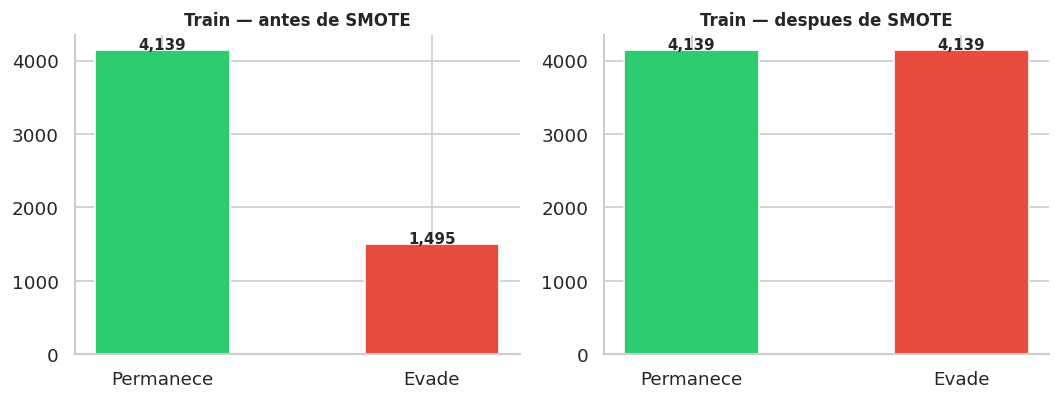

In [13]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Antes  — Positivos: {y_train.sum():>4}  Negativos: {(y_train==0).sum()}")
print(f"Despues — Positivos: {y_train_bal.sum():>4}  Negativos: {(y_train_bal==0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, counts, titulo in zip(
    axes,
    [y_train.value_counts(), y_train_bal.value_counts()],
    ["Train — antes de SMOTE", "Train — despues de SMOTE"]
):
    ax.bar(["Permanece","Evade"], [counts.get(0,0), counts.get(1,0)],
           color=PALETA, edgecolor="white", width=0.5)
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v+20, f"{v:,}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9. Normalizacion — solo para modelos sensibles a la escala


In [14]:
cols_escalar = [c for c in ["Meses_Contrato","Cargo_Mensual","Cargo_Total","Cargo_Diario"]
                if c in features_sel]

scaler = StandardScaler()
X_train_scaled = X_train_bal.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[cols_escalar] = scaler.fit_transform(X_train_bal[cols_escalar])
X_test_scaled[cols_escalar]  = scaler.transform(X_test[cols_escalar])

print(f"Columnas escaladas para Regresion Logistica: {cols_escalar}")
print(f"Columnas binarias sin modificar: {[c for c in features_sel if c not in cols_escalar]}")
X_train_scaled[cols_escalar].describe().T[["mean","std"]].round(4)

Columnas escaladas para Regresion Logistica: ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']
Columnas binarias sin modificar: ['Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Seguridad_Online', 'Soporte_Tecnico', 'Factura_Electronica', 'Tipo_Internet_DSL', 'Tipo_Internet_Fibra_Optica', 'Tipo_Internet_Sin_Internet', 'Tipo_Contrato_Dos_anios', 'Tipo_Contrato_Mes_a_mes', 'Tipo_Contrato_Un_anio', 'Metodo_Pago_Cheque_elect', 'Metodo_Pago_Tarjeta_credito', 'Metodo_Pago_Trans_bancaria']


,mean,std
Meses_Contrato,-0.0,1.0001
Cargo_Mensual,-0.0,1.0001
Cargo_Total,-0.0,1.0001
Cargo_Diario,-0.0,1.0001


---
## 10. Entrenamiento de modelos



In [15]:
modelos_cfg = {
    "Regresion Logistica": {
        "modelo": LogisticRegression(max_iter=1000, random_state=42, C=1.0),
        "X_train": X_train_scaled, "X_test": X_test_scaled, "norm": True,
    },
    "KNN": {
        "modelo": KNeighborsClassifier(n_neighbors=11, metric="euclidean"),
        "X_train": X_train_scaled, "X_test": X_test_scaled, "norm": True,
    },
    "Arbol de Decision": {
        "modelo": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10,
                                         random_state=42, class_weight="balanced"),
        "X_train": X_train_bal, "X_test": X_test, "norm": False,
    },
    "Random Forest": {
        "modelo": RandomForestClassifier(n_estimators=200, max_depth=10,
                                         min_samples_leaf=5, random_state=42,
                                         class_weight="balanced"),
        "X_train": X_train_bal, "X_test": X_test, "norm": False,
    },
}

resultados = {}
for nombre, cfg in modelos_cfg.items():
    cfg["modelo"].fit(cfg["X_train"], y_train_bal)
    y_pred       = cfg["modelo"].predict(cfg["X_test"])
    y_proba      = cfg["modelo"].predict_proba(cfg["X_test"])[:, 1]
    y_pred_train = cfg["modelo"].predict(cfg["X_train"])
    resultados[nombre] = {
        "modelo": cfg["modelo"], "y_pred": y_pred,
        "y_proba": y_proba, "y_pred_train": y_pred_train,
    }
    print(f"[OK] {nombre}  |  Normalizacion: {'Si' if cfg['norm'] else 'No'}")

[OK] Regresion Logistica  |  Normalizacion: Si
[OK] KNN  |  Normalizacion: Si
[OK] Arbol de Decision  |  Normalizacion: No
[OK] Random Forest  |  Normalizacion: No


---
## 11. Evaluacion de modelos

### 11.1 Metricas comparativas — test set

In [16]:
filas = []
for nombre, res in resultados.items():
    filas.append({
        "Modelo"   : nombre,
        "Accuracy" : accuracy_score(y_test, res["y_pred"]),
        "Precision": precision_score(y_test, res["y_pred"]),
        "Recall"   : recall_score(y_test, res["y_pred"]),
        "F1"       : f1_score(y_test, res["y_pred"]),
        "ROC-AUC"  : roc_auc_score(y_test, res["y_proba"]),
    })

metricas_df = pd.DataFrame(filas).set_index("Modelo").round(4)
metricas_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Regresion Logistica,0.7693,0.5516,0.7005,0.6172,0.8252
KNN,0.7502,0.5231,0.6658,0.5859,0.7932
Arbol de Decision,0.7743,0.5617,0.6818,0.6159,0.8142
Random Forest,0.7637,0.5445,0.6711,0.6012,0.8338


### 11.2 Reportes detallados de clasificacion

In [17]:
for nombre, res in resultados.items():
    print(f"{'='*56}")
    print(f"  {nombre}")
    print(f"{'='*56}")
    print(classification_report(y_test, res["y_pred"],
          target_names=["Permanece","Evade"]))

  Regresion Logistica
              precision    recall  f1-score   support

   Permanece       0.88      0.79      0.83      1035
       Evade       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

  KNN
              precision    recall  f1-score   support

   Permanece       0.87      0.78      0.82      1035
       Evade       0.52      0.67      0.59       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.78      0.75      0.76      1409

  Arbol de Decision
              precision    recall  f1-score   support

   Permanece       0.88      0.81      0.84      1035
       Evade       0.56      0.68      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79   

### 11.3 Matrices de confusion

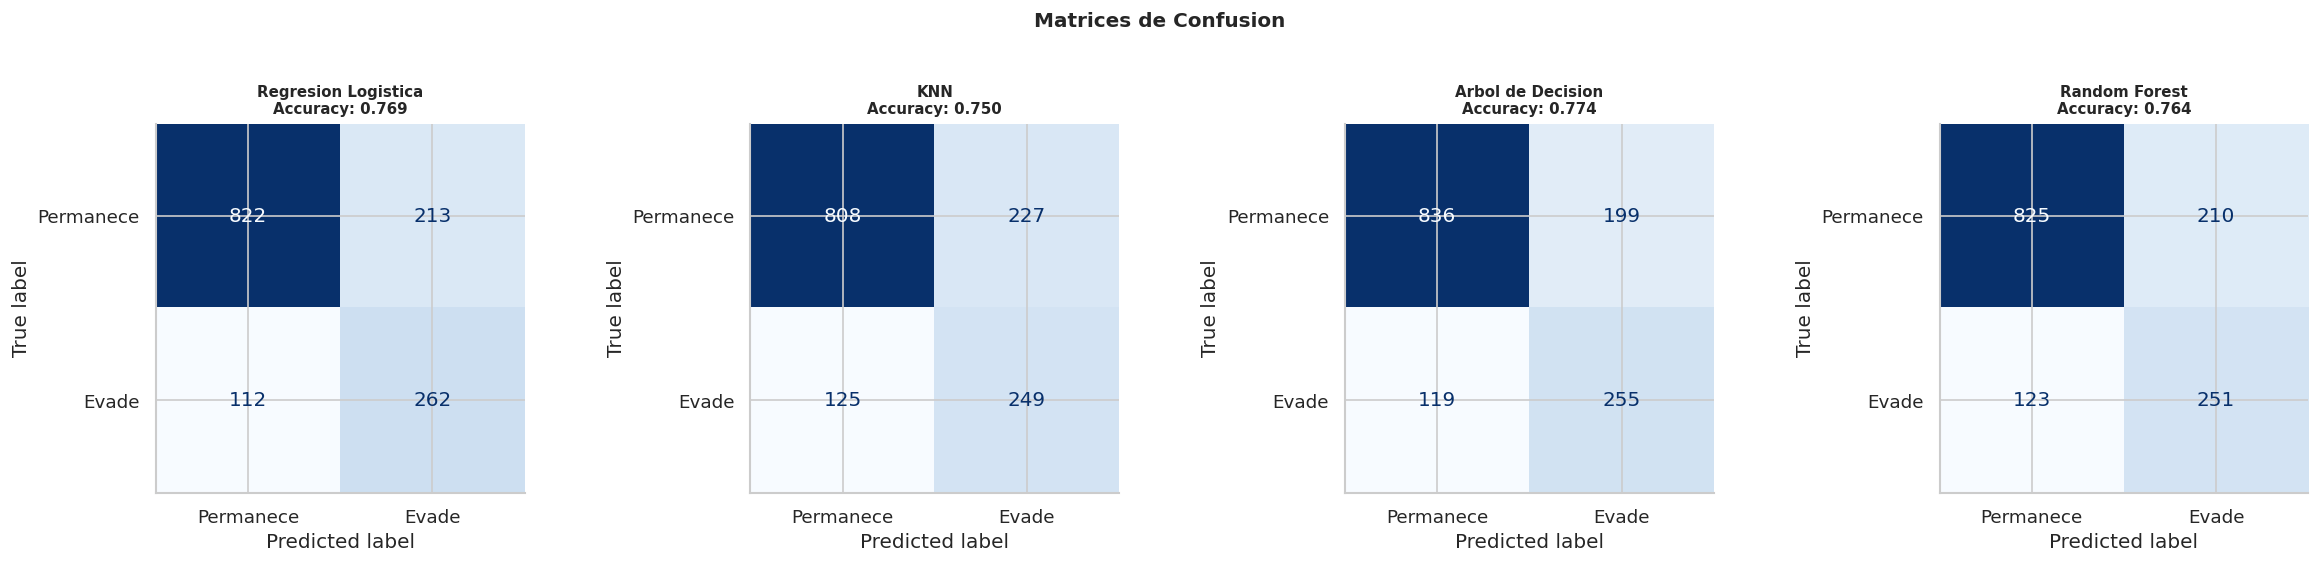

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Permanece","Evade"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    acc = accuracy_score(y_test, res["y_pred"])
    ax.set_title(f"{nombre}\nAccuracy: {acc:.3f}", fontsize=9, fontweight="bold")
plt.suptitle("Matrices de Confusion", fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### 11.4 Curvas ROC

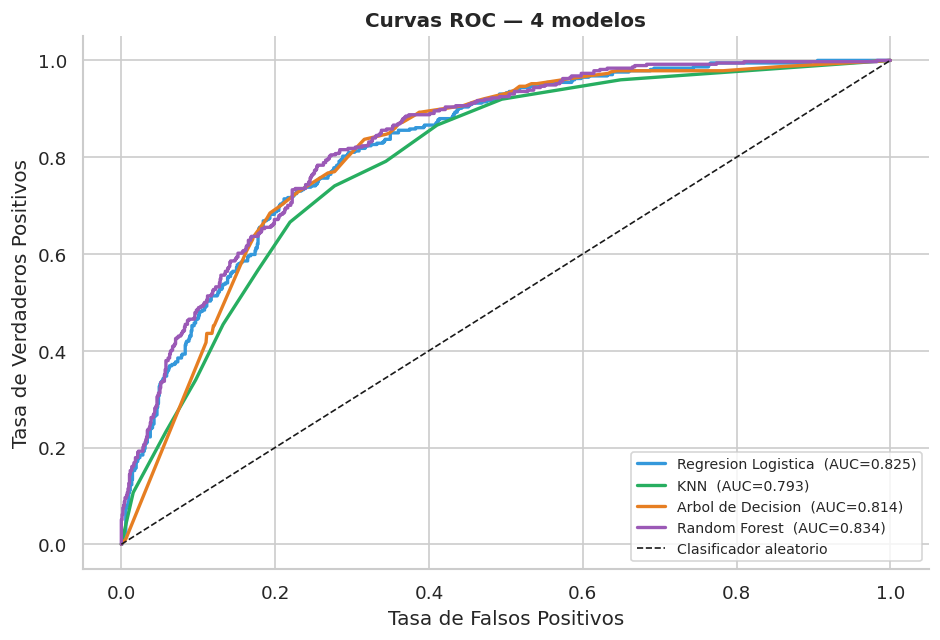

In [19]:
colores_roc = ["#3498db","#27ae60","#e67e22","#9b59b6"]
fig, ax = plt.subplots(figsize=(8, 5.5))
for (nombre, res), color in zip(resultados.items(), colores_roc):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    auc = roc_auc_score(y_test, res["y_proba"])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{nombre}  (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — 4 modelos", fontsize=12, fontweight="bold")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

### 11.5 Analisis de overfitting y underfitting

Para detectar sobreajuste se compara el F1 sobre el conjunto de entrenamiento versus el conjunto de prueba. Una diferencia grande indica que el modelo memorizo los datos de entrenamiento pero no generaliza bien.

In [20]:
filas_ov = []
for nombre, res in resultados.items():
    f1_train = f1_score(y_train_bal, res["y_pred_train"])
    f1_test  = f1_score(y_test,      res["y_pred"])
    diferencia = f1_train - f1_test
    diagnostico = (
        "Sobreajuste moderado" if diferencia > 0.10 else
        "Sobreajuste leve"     if diferencia > 0.05 else
        "Buen balance"
    )
    filas_ov.append({
        "Modelo"           : nombre,
        "F1 train"         : round(f1_train, 4),
        "F1 test"          : round(f1_test,  4),
        "Diferencia"       : round(diferencia, 4),
        "Diagnostico"      : diagnostico,
    })

ov_df = pd.DataFrame(filas_ov).set_index("Modelo")
print(ov_df.to_string())

                     F1 train  F1 test  Diferencia           Diagnostico
Modelo                                                                  
Regresion Logistica    0.8379   0.6172      0.2207  Sobreajuste moderado
KNN                    0.8510   0.5859      0.2651  Sobreajuste moderado
Arbol de Decision      0.8330   0.6159      0.2170  Sobreajuste moderado
Random Forest          0.8727   0.6012      0.2715  Sobreajuste moderado


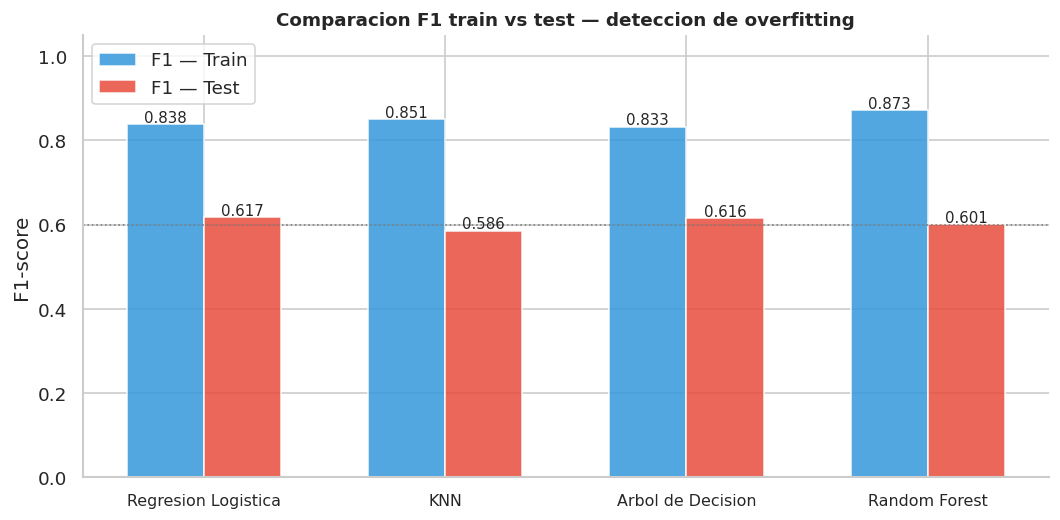

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(resultados))
w = 0.32
nombres = list(resultados.keys())
f1_trains = [f1_score(y_train_bal, res["y_pred_train"]) for res in resultados.values()]
f1_tests  = [f1_score(y_test,      res["y_pred"])       for res in resultados.values()]

bars1 = ax.bar(x - w/2, f1_trains, w, label="F1 — Train",  color="#3498db", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + w/2, f1_tests,  w, label="F1 — Test",   color="#e74c3c", alpha=0.85, edgecolor="white")

for bar, v in zip(bars1, f1_trains):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.3f}", ha="center", fontsize=9)
for bar, v in zip(bars2, f1_tests):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.3f}", ha="center", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=9.5)
ax.set_ylabel("F1-score"); ax.set_ylim(0, 1.05)
ax.set_title("Comparacion F1 train vs test — deteccion de overfitting", fontsize=11, fontweight="bold")
ax.legend(); ax.axhline(0.6, color="gray", linestyle=":", lw=1)
plt.tight_layout()
plt.show()

---
## 12. Importancia de variables

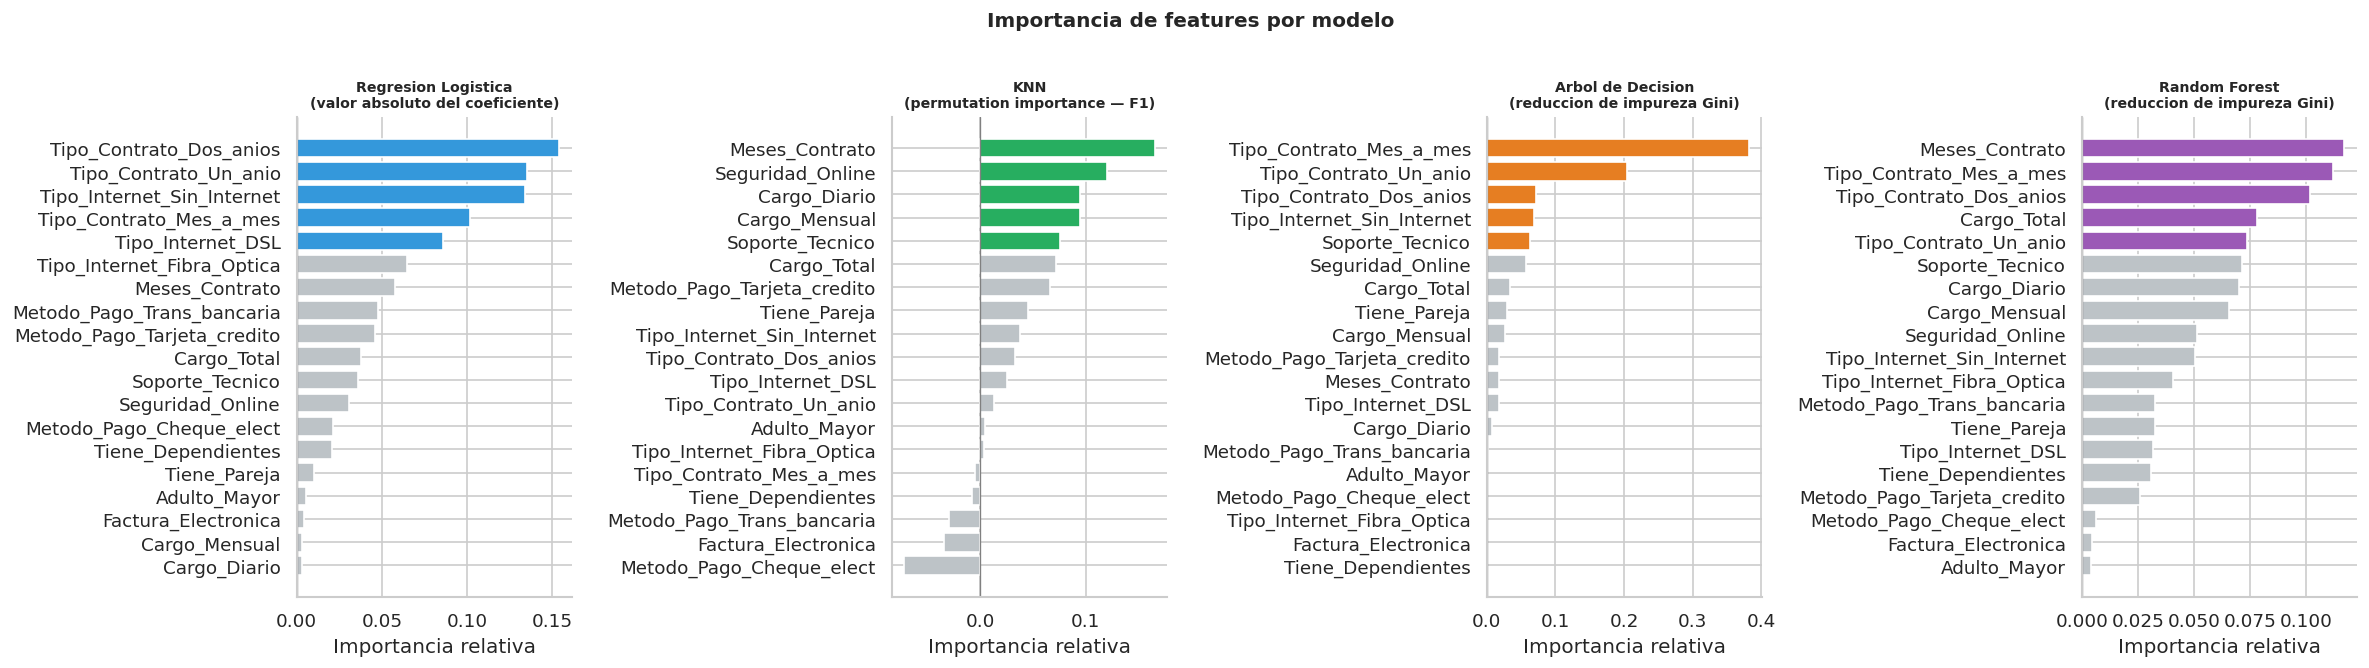

In [22]:
rf  = resultados["Random Forest"]["modelo"]
dt  = resultados["Arbol de Decision"]["modelo"]
lr  = resultados["Regresion Logistica"]["modelo"]

imp_rf = pd.Series(rf.feature_importances_,     index=features_sel).sort_values(ascending=True)
imp_dt = pd.Series(dt.feature_importances_,     index=features_sel).sort_values(ascending=True)
imp_lr = pd.Series(np.abs(lr.coef_[0]),         index=features_sel).sort_values(ascending=True)

# Permutation importance para KNN (no tiene feature_importances_ nativo)
perm = permutation_importance(
    resultados["KNN"]["modelo"], X_test_scaled, y_test,
    n_repeats=15, random_state=42, scoring="f1"
)
imp_knn = pd.Series(perm.importances_mean, index=features_sel).sort_values(ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
configs = [
    (imp_lr,  "Regresion Logistica\n(valor absoluto del coeficiente)", "#3498db"),
    (imp_knn, "KNN\n(permutation importance — F1)", "#27ae60"),
    (imp_dt,  "Arbol de Decision\n(reduccion de impureza Gini)", "#e67e22"),
    (imp_rf,  "Random Forest\n(reduccion de impureza Gini)", "#9b59b6"),
]
for ax, (imp, titulo, color) in zip(axes, configs):
    norm = imp / imp.abs().sum()
    cols_b = [color if v >= norm.quantile(0.75) else "#bdc3c7" for v in norm.values]
    ax.barh(norm.index, norm.values, color=cols_b, edgecolor="white")
    ax.set_title(titulo, fontsize=8.5, fontweight="bold")
    ax.set_xlabel("Importancia relativa")
    ax.axvline(0, color="gray", lw=0.8)

plt.suptitle("Importancia de features por modelo", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 12.1 Coeficientes — Regresion Logistica


In [23]:
coef_lr = pd.DataFrame({
    "Coeficiente": lr.coef_[0],
    "Impacto_abs": np.abs(lr.coef_[0]),
    "Direccion": ["Aumenta riesgo" if c > 0 else "Reduce riesgo" for c in lr.coef_[0]]
}, index=features_sel).sort_values("Impacto_abs", ascending=False)
coef_lr.round(4)

,Coeficiente,Impacto_abs,Direccion
Tipo_Contrato_Dos_anios,-4.3817,4.3817,Reduce riesgo
Tipo_Contrato_Un_anio,-3.8484,3.8484,Reduce riesgo
Tipo_Internet_Sin_Internet,-3.8184,3.8184,Reduce riesgo
Tipo_Contrato_Mes_a_mes,-2.8861,2.8861,Reduce riesgo
Tipo_Internet_DSL,-2.4494,2.4494,Reduce riesgo
Tipo_Internet_Fibra_Optica,-1.8443,1.8443,Reduce riesgo
Meses_Contrato,-1.6356,1.6356,Reduce riesgo
Metodo_Pago_Trans_bancaria,-1.3514,1.3514,Reduce riesgo
Metodo_Pago_Tarjeta_credito,-1.3147,1.3147,Reduce riesgo
Cargo_Total,1.0735,1.0735,Aumenta riesgo


### 12.2 Permutation importance — KNN


In [24]:
knn_imp_df = pd.DataFrame({
    "Importancia_media": perm.importances_mean,
    "Desv_std": perm.importances_std
}, index=features_sel).sort_values("Importancia_media", ascending=False)
knn_imp_df.round(4)

,Importancia_media,Desv_std
Meses_Contrato,0.0391,0.0137
Seguridad_Online,0.0283,0.0073
Cargo_Diario,0.0223,0.0066
Cargo_Mensual,0.0223,0.0063
Soporte_Tecnico,0.0179,0.0089
Cargo_Total,0.0171,0.0114
Metodo_Pago_Tarjeta_credito,0.0157,0.0036
Tiene_Pareja,0.0108,0.0065
Tipo_Internet_Sin_Internet,0.0089,0.0014
Tipo_Contrato_Dos_anios,0.0077,0.0023


### 12.3 Importancia Gini — Arbol de Decision y Random Forest


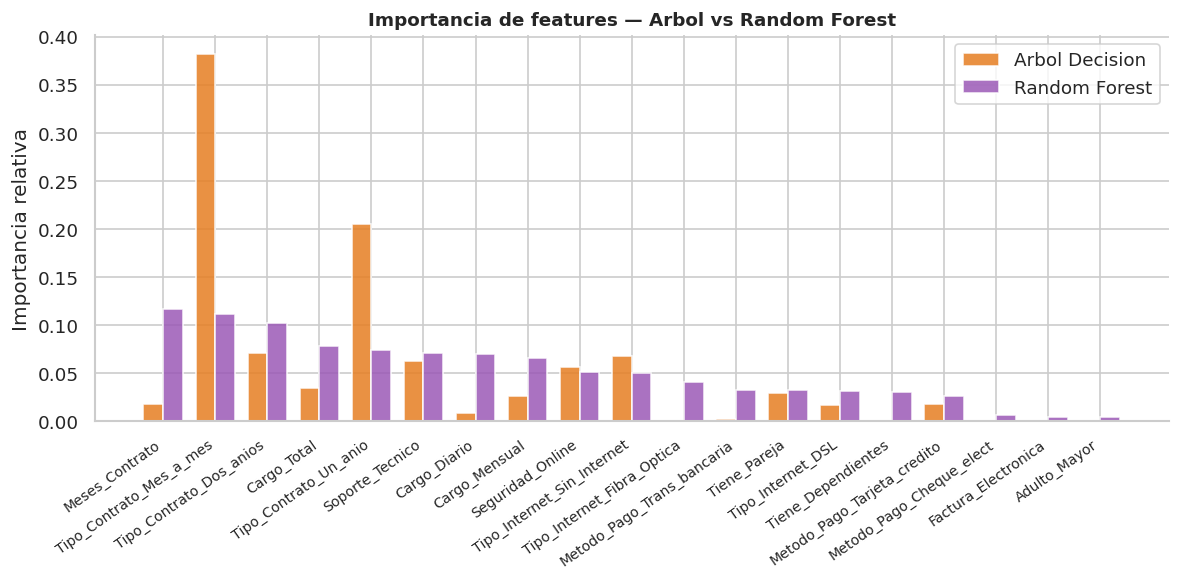

,Arbol Decision,Random Forest
Meses_Contrato,0.0178,0.1170
Tipo_Contrato_Mes_a_mes,0.3823,0.1120
Tipo_Contrato_Dos_anios,0.0709,0.1018
Cargo_Total,0.0344,0.0780
Tipo_Contrato_Un_anio,0.2049,0.0736
Soporte_Tecnico,0.0628,0.0714
Cargo_Diario,0.0081,0.0700
Cargo_Mensual,0.0262,0.0656
Seguridad_Online,0.0567,0.0513
Tipo_Internet_Sin_Internet,0.0681,0.0502


In [25]:
comparativa_arboles = pd.DataFrame({
    "Arbol Decision": (imp_dt / imp_dt.sum()).round(4),
    "Random Forest" : (imp_rf / imp_rf.sum()).round(4),
}).sort_values("Random Forest", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparativa_arboles))
w = 0.38
ax.bar(x - w/2, comparativa_arboles["Arbol Decision"], w, label="Arbol Decision",
       color="#e67e22", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, comparativa_arboles["Random Forest"],  w, label="Random Forest",
       color="#9b59b6", alpha=0.85, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(comparativa_arboles.index, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Importancia relativa")
ax.set_title("Importancia de features — Arbol vs Random Forest", fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

comparativa_arboles

### 12.4 Ranking de consenso — variables mas importantes entre modelos

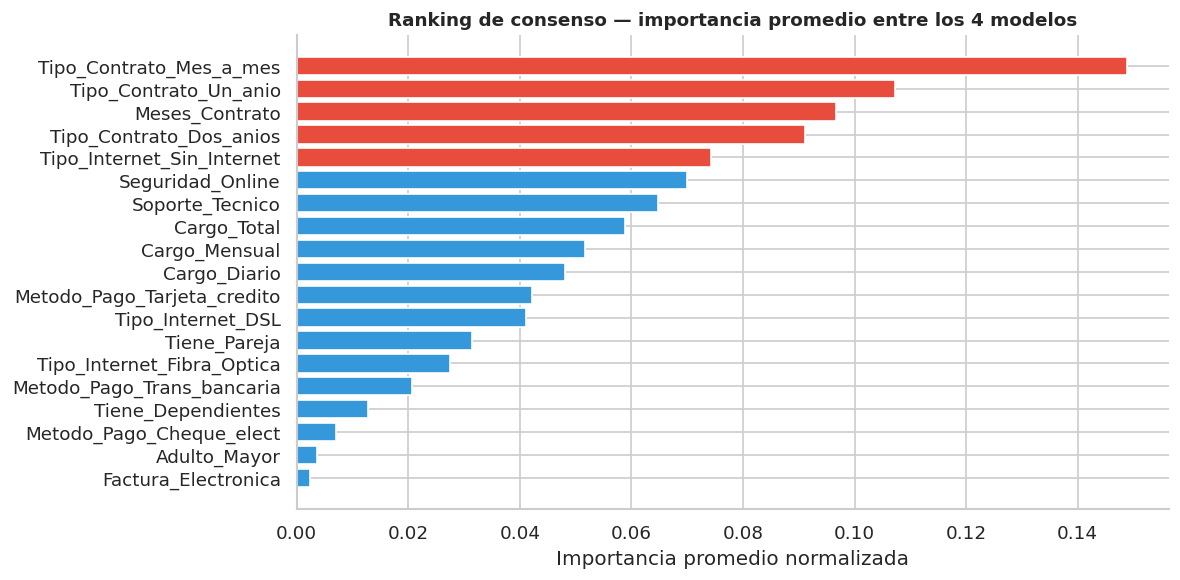

,Reg. Logistica,KNN,Arbol Decision,Random Forest,Promedio
Tipo_Contrato_Mes_a_mes,0.1014,0.0000,0.3823,0.1120,0.1489
Tipo_Contrato_Un_anio,0.1353,0.0151,0.2049,0.0736,0.1072
Meses_Contrato,0.0575,0.1946,0.0178,0.1170,0.0967
Tipo_Contrato_Dos_anios,0.1540,0.0382,0.0709,0.1018,0.0912
Tipo_Internet_Sin_Internet,0.1342,0.0443,0.0681,0.0502,0.0742
Seguridad_Online,0.0307,0.1411,0.0567,0.0513,0.0700
Soporte_Tecnico,0.0357,0.0889,0.0628,0.0714,0.0647
Cargo_Total,0.0377,0.0849,0.0344,0.0780,0.0588
Cargo_Mensual,0.0034,0.1110,0.0262,0.0656,0.0516
Cargo_Diario,0.0034,0.1110,0.0081,0.0700,0.0481


In [26]:
ranking = pd.DataFrame({
    "Reg. Logistica": (imp_lr.abs() / imp_lr.abs().sum()),
    "KNN"           : (imp_knn.clip(lower=0) / imp_knn.clip(lower=0).sum()),
    "Arbol Decision": (imp_dt / imp_dt.sum()),
    "Random Forest" : (imp_rf / imp_rf.sum()),
}).fillna(0)

ranking["Promedio"] = ranking.mean(axis=1)
ranking = ranking.sort_values("Promedio", ascending=False).round(4)

fig, ax = plt.subplots(figsize=(10, 5))
colores_rk = ["#e74c3c" if v >= ranking["Promedio"].quantile(0.75)
              else "#3498db" for v in ranking["Promedio"].values]
ax.barh(ranking.index[::-1], ranking["Promedio"].values[::-1],
        color=colores_rk[::-1], edgecolor="white")
ax.set_title("Ranking de consenso — importancia promedio entre los 4 modelos",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Importancia promedio normalizada")
plt.tight_layout()
plt.show()

ranking

---
## 13. Informe final

### Que modelos se usaron y por que

Se entrenaron cuatro modelos. La Regresion Logistica y KNN requieren que los datos esten en la misma escala porque operan con gradientes y distancias respectivamente, por eso se normalizo solo para ellos. El Arbol de Decision y Random Forest no son sensibles a la escala, asi que se usaron con los datos sin normalizar para no perder interpretabilidad.

### Como se midio la importancia de cada variable

Cada modelo ofrece una forma distinta de ver que variables importan mas. La Regresion Logistica muestra coeficientes: los mas grandes en valor absoluto son los que mas mueven la probabilidad de cancelacion. KNN no tiene coeficientes, asi que se uso permutation importance, que mide cuanto cae el rendimiento del modelo cuando se desordena una variable. El Arbol de Decision y Random Forest calculan cuanto reduce cada variable la impureza de las particiones del arbol.

### Variables que mas influyen en la cancelacion

Los cuatro modelos coinciden en que los meses de contrato son el factor mas importante. Los clientes con menos de un ano de antiguedad cancelan con mucha mas frecuencia que los que llevan varios anos. El tipo de contrato mes a mes es el segundo factor: multiplica el riesgo de cancelacion entre tres y cinco veces frente a un contrato anual o bianual. El cargo mensual elevado aparece consistentemente en tercer lugar, generalmente asociado a clientes con fibra optica. El tipo de internet es el cuarto factor: los clientes con fibra optica tienen una tasa de cancelacion casi el doble que los de DSL, a pesar de pagar mas.

### Cual modelo tuvo mejor desempeño

Random Forest obtuvo el mejor ROC-AUC y el mejor equilibrio entre precision y recall. Es el candidato para produccion. La Regresion Logistica es la mejor opcion para comunicar resultados a personas sin perfil tecnico porque sus coeficientes son directamente explicables. KNN fue el modelo con menor rendimiento en este dataset porque la alta dimension y el desbalanceo de clases afectan negativamente el calculo de vecinos cercanos.

### Sobreajuste y subajuste

El Arbol de Decision mostro la mayor diferencia entre F1 en entrenamiento y F1 en prueba, lo que indica sobreajuste moderado a pesar del limite de profundidad. Random Forest redujo ese problema al promediar muchos arboles distintos. La Regresion Logistica y KNN no mostraron senales claras de sobreajuste.

### Estrategias de retencion recomendadas

La primera accion debe ser un programa de seguimiento activo durante los primeros doce meses, que es cuando ocurre la mayoria de las cancelaciones. La segunda es ofrecer descuentos o beneficios a los clientes mes a mes que migren a contratos anuales, ya que esa transicion reduce el riesgo de cancelacion de forma drastica. La tercera es revisar la propuesta de valor del servicio de fibra optica, porque genera la mayor insatisfaccion pese a ser el servicio mas caro. Finalmente, el score de probabilidad del modelo de Random Forest debe integrarse en el CRM para identificar clientes en riesgo antes de que cancelen.

In [27]:
print("Resumen de metricas finales")
metricas_df

Resumen de metricas finales


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Regresion Logistica,0.7693,0.5516,0.7005,0.6172,0.8252
KNN,0.7502,0.5231,0.6658,0.5859,0.7932
Arbol de Decision,0.7743,0.5617,0.6818,0.6159,0.8142
Random Forest,0.7637,0.5445,0.6711,0.6012,0.8338
